# Proyek Klasifikasi Gambar: [Nature Scenes Classification]
- **Nama:** [Mayang Gumelar]
- **Email:** [m604d5x1090@student.devacademy.id]
- **ID Dicoding:** [M604D5X1090]

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library pokok
import os, shutil # os = per-folderan dan path // shutil pindah file = atur dataset (train,test,hapus)
import io # input output
import zipfile # pembuka ritsleting = ekstrak data
import random # pe-random file gambar untuk split
from importlib.metadata import distribution
from random import sample # pe-random file gambar untuk split
from shutil import copyfile # penyalin file 1/1 ke folder train or val
import pathlib
from pathlib import Path # penyihir jalur file tanpa worry / or \
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.python.keras.layers import GlobalAvgPool2D
from tqdm.notebook import tqdm as tq # bar indikator oke untuk informasikan proses pelatihan data

# Pemrosesan Data Gambar
import cv2 # olah gambar, konversi ruang warna
from PIL import Image # manajer image, operasi gambar
import skimage # preprocessing gambar
from skimage.transform import resize # ubah ukuran
from skimage.transform import rotate, AffineTransform, warp # augmentasi
from skimage import img_as_ubyte # standarisasi format gambar ke 0-255
from skimage.exposure import adjust_gamma # augmentasi cahaya
from skimage.util import random_noise # augmentasi buram

# Latih model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping
!pip install tensorflowjs
import tensorflowjs as tfjs

In [2]:
# cozy code
import warnings
warnings.simplefilter(action='ignore') # nonaktifkan warning

## Data Preparation

### Data Loading

In [ ]:
path = "D:/python/PyCharmMiscProject/SDL_MAYANG_GUMELAR/nature_scenes"
print("Path to dataset files:", path)

Path to dataset files: D:/python/PyCharmMiscProject/SDL_MAYANG_GUMELAR/nature_scenes


In [ ]:
# Menentukan direktori awal untuk data train dan test
train_dir = "nature_scenes/seg_train"
test_dir = "nature_scenes/seg_test"

# direktori baru data gabungan
combined_dir = "nature_scenes/dataset"

# buat direktori baru untuk data gabungan
os.makedirs(combined_dir, exist_ok=True)

In [ ]:
# Menyalin data train ke data gabungan
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Menyalin data test ke data gabungan
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

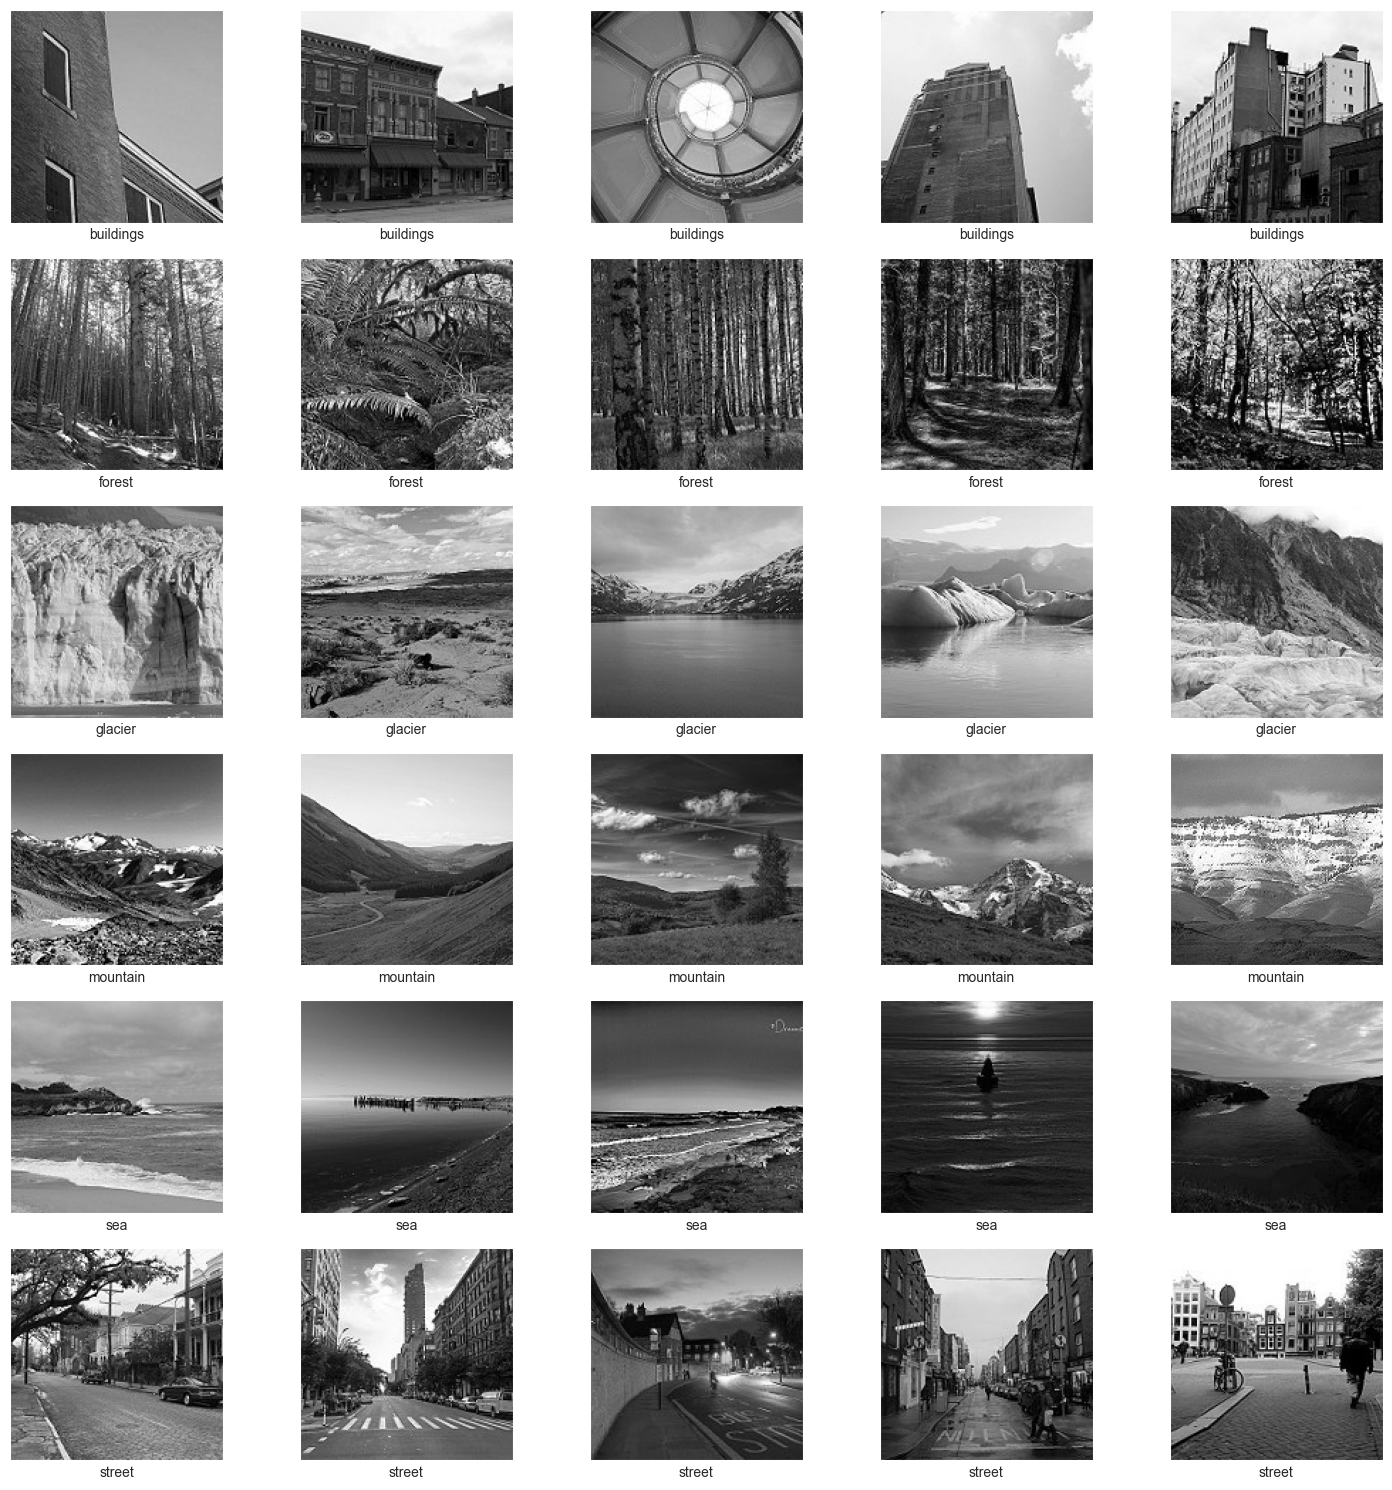

In [ ]:
# Checking Dataset
# Kamus untuk simpan daftar gambar setiap kelas
skin_image = {}

# path sumber train
path = "nature_scenes/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    skin_image[i] = os.listdir(os.path.join(path_sub,i))

# Menampilkan acak 5 gambar di bawah setiap dari 2 kelas dari data.
path_sub = "nature_scenes/dataset/"

# Menampilkan acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(skin_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(skin_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

In [ ]:
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total_images += num_images

        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")
        print("---------------")

    print(f"\nTotal: {total_images}")

In [ ]:
# Cek resolusi gambar
print_images_resolution(combined_dir)

buildings: 2628
- (150, 124)
- (150, 150)
---------------
forest: 2745
- (150, 136)
- (150, 113)
- (150, 135)
- (150, 141)
- (150, 115)
- (150, 150)
- (150, 124)
- (150, 108)
- (150, 133)
---------------
glacier: 2957
- (150, 136)
- (150, 142)
- (150, 105)
- (150, 102)
- (150, 108)
- (150, 111)
- (150, 120)
- (150, 123)
- (150, 135)
- (150, 141)
- (150, 150)
- (150, 110)
- (150, 113)
- (150, 119)
- (150, 76)
- (150, 134)
- (150, 143)
- (150, 146)
- (150, 149)
- (150, 97)
- (150, 115)
- (150, 124)
- (150, 133)
- (150, 72)
---------------
mountain: 3037
- (150, 136)
- (150, 81)
- (150, 145)
- (150, 142)
- (150, 105)
- (150, 102)
- (150, 108)
- (150, 111)
- (150, 120)
- (150, 123)
- (150, 135)
- (150, 141)
- (150, 144)
- (150, 150)
- (150, 147)
- (150, 110)
- (150, 113)
- (150, 119)
- (150, 131)
- (150, 76)
- (150, 134)
- (150, 143)
- (150, 146)
- (150, 149)
- (150, 100)
- (150, 97)
- (150, 103)
- (150, 115)
- (150, 124)
- (150, 133)
- (150, 72)
---------------
sea: 2784
- (150, 136)
- (1

**TOTAL ADA 17034 IMAGES DENGAN RESOLUSI YANG BERBEDA-BEDA**

### Plot Distribusi Data

In [ ]:
# definisikan path sumber
skin_path = "nature_scenes/dataset/"

# buat daftar yang menyimpan data untuk setiap nama file, labels, dan path file
file_name = [] # simpan nama file
labels = [] # simpan nama kelas
full_path = [] # simpan jalur lengkap

# Dapatkan nama, label, path lalu simpan sbg dataframe
for path, subdirs, files in os.walk(skin_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name) # simpan nama file saja

In [ ]:
jml_images = len(labels)
print("Jumlah Images: ", jml_images)

Jumlah Images:  17034


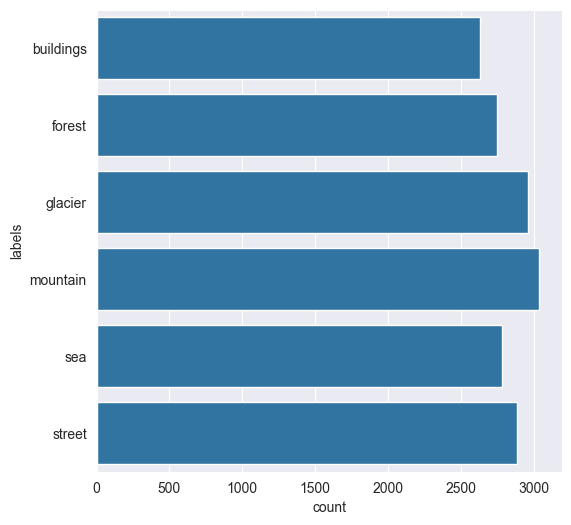

In [ ]:
distribution_train = pd.DataFrame({"path":full_path, "file_name":file_name, "labels":labels})

# plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

**Penjelasan :**
Semua label memiliki rata-rata jumlah image diantara 2500 - 3000 data. Augmentasi akan dilakukan pada building, forest, dan sea

### Data Augmented

In [ ]:
# Fungsi anticlockwise
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    sudut = random.randint(10, 180)
    return rotate(img, sudut)

# Fungsi clockwise
def clockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    sudut = random.randint(10, 180)
    return rotate(img, -sudut)

# Fungsi flip
def flip_up_down(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    return np.flip(img)

# Brightness
def add_brightness(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 224))
    img = adjust_gamma(img, gamma=0.5,gain=1)
    return img

# Blur Effect
def add_blur(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    return cv2.GaussianBlur(img, (9,9), 0)

# Geser Acak
def sheared(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    transform = AffineTransform(shear=0.2)
    shear_img = warp(img, transform, mode="wrap")
    return shear_img

# Geser Lengkung
def warp_shift(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    transform = AffineTransform(translation=(0,40))
    warp_img = warp(img, transform, mode="wrap")
    return warp_img

In [ ]:
# Membuat variabel transformasi
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': add_blur,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared}

def augmented_images(images_path, augmented_path, images_to_generate):
    images = [] # Penyimpanan gambar yang telah melalui pra-pemrosesan

    # Baca nama gambar dari folder dan tambahkan path ke images[]
    for im in os.listdir(images_path):
        images.append(os.path.join(images_path, im))

    # jumalah gambar akan di augmentasi
    i=1

    while i<=images_to_generate:
        image=random.choice(images) # ambil dari list images[]
        try:
            original_image = cv2.imread(image)
            transformed_image=None
            n = 0
            transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang diterapkan

            while n <= transformation_count:
                key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
                transformed_image = transformations[key](original_image)
                n = n + 1

            new_image_path= "%s/augmented_%s.jpg" %(augmented_path, i)
            transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
            cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
            i =i+1
        except ValueError as e:
            print('could not read the',image ,':',e,'hence skipping it.')

In [ ]:
# Augmentasi buildings
buildings_path = 'nature_scenes/dataset/buildings'
buildings_path_aug = 'nature_scenes/dataset/buildings_aug'

augmented_images(buildings_path, buildings_path_aug, 400) # tambah 400 gambar

In [ ]:
# Augmentasi forest
forest_path = 'nature_scenes/dataset/forest'
forest_path_aug = 'nature_scenes/dataset/forest_aug'

augmented_images(forest_path, forest_path_aug, 300) # tambah 300 gambar

In [ ]:
# Augmentasi sea
sea_path = 'nature_scenes/dataset/sea'
sea_path_aug = 'nature_scenes/dataset/sea_aug'

augmented_images(sea_path, sea_path_aug, 300) # tambah 300 gambar

In [ ]:
# Pindahkan dari folder hasil augmentasi ke folder utama label
def move_image(start_folder, end_folder):
    os.makedirs(end_folder, exist_ok=True)

    for file in os.listdir(start_folder):
        src = os.path.join(start_folder, file)
        dst = os.path.join(end_folder, file)

        if os.path.isfile(src) and file.lower().endswith(('.jpg', '.jpeg', '.png')):
            shutil.move(src, dst)
    print("All images moved!")

In [ ]:
# Buildings
move_image(buildings_path_aug, buildings_path)

# Forest
move_image(forest_path_aug, forest_path)

# Sea
move_image(sea_path_aug, sea_path)

All images moved!
All images moved!
All images moved!


In [ ]:
# Hapus folder
folder_del = [buildings_path_aug, forest_path_aug, sea_path_aug]

for dir in folder_del:
    shutil.rmtree(dir)
    print("Folder deleted")

Folder deleted
Folder deleted
Folder deleted


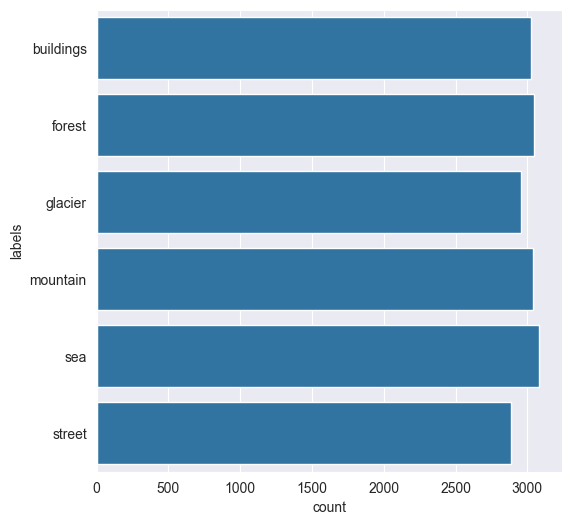

In [ ]:
skin_path_new = "nature_scenes/dataset/"

file_name = []
labels = []
full_path = []

# Dapatkan nama, label, path lalu simpan sbg dataframe
for path, subdirs, files in os.walk(skin_path_new):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, "file_name":file_name, "labels":labels})

# plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

**Penjelasan :**
Sekarang data sudah balance

### Data Preprocessing

#### Split Dataset

In [ ]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'nature_scenes/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

labels
buildings    3028
forest       3045
glacier      2957
mountain     3037
sea          3084
street       2883
dtype: int64

In [ ]:
# Variabel yang digunakan pada pemisahan
X = df['path']
y= df['labels']

# Split dataset tahap 1
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=300)

# Split dataset tahap 2
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=300)

In [ ]:
# Menyatukan ke dalam masing2 dataframe
df_tr = pd.DataFrame({'path':X_train, 'labels':y_train, 'set':'train'})
df_vl = pd.DataFrame({'path':X_val, 'labels':y_val, 'set':'val'})
df_te = pd.DataFrame({'path':X_test, 'labels':y_test, 'set':'test'})

In [ ]:
df_tr.head()

,path,labels,set
13997,nature_scenes/dataset/sea\345.jpg,sea,train
16181,nature_scenes/dataset/street\17463.jpg,street,train
8419,nature_scenes/dataset/glacier\5348.jpg,glacier,train
13866,nature_scenes/dataset/sea\2462.jpg,sea,train
10034,nature_scenes/dataset/mountain\17240.jpg,mountain,train


In [ ]:
df_vl.count()

path      2705
labels    2705
set       2705
dtype: int64

In [ ]:
df_te.count()

path      2706
labels    2706
set       2706
dtype: int64

In [ ]:
# Gabung dataset
df_all = pd.concat([df_tr, df_vl, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel
print(df_all.sample(5))


set    labels   
test   buildings     447
       forest        442
       glacier       450
       mountain      449
       sea           477
       street        441
train  buildings    2136
       forest       2179
       glacier      1992
       mountain     2144
       sea          2137
       street       2035
val    buildings     445
       forest        424
       glacier       515
       mountain      444
       sea           470
       street        407
dtype: int64 


                                           path    labels    set
11165   nature_scenes/dataset/glacier\11787.jpg   glacier  train
10520     nature_scenes/dataset/street\4815.jpg    street  train
16679   nature_scenes/dataset/glacier\18361.jpg   glacier   test
1609      nature_scenes/dataset/street\1297.jpg    street  train
4083   nature_scenes/dataset/mountain\21226.jpg  mountain  train


### Image Generator

In [ ]:
# Buat variabel ImageDataGenerator untuk menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(df_tr,
                                              x_col='path',
                                              y_col='labels',
                                              batch_size=32,
                                              target_size=(244, 244),
                                              color_mode='rgb',
                                              class_mode='categorical',
                                              rotation_range=20,
                                              width_shift_range=0.2,
                                              height_shift_range=0.2,
                                              shear_range=0.2,
                                              zoom_range=0.2,
                                              horizontal_flip=True,
                                              fill_mode='nearest',
                                              shuffle=True)

val_gen = datagen.flow_from_dataframe(df_vl,
                                              x_col='path',
                                              y_col='labels',
                                              batch_size=32,
                                              target_size=(244, 244),
                                              color_mode='rgb',
                                              class_mode='categorical',
                                              rotation_range=20,
                                              width_shift_range=0.2,
                                              height_shift_range=0.2,
                                              shear_range=0.2,
                                              zoom_range=0.2,
                                              horizontal_flip=True,
                                              fill_mode='nearest',
                                              shuffle=False)

test_gen = test_datagen.flow_from_dataframe(df_te,
                                              x_col='path',
                                              y_col='labels',
                                              batch_size=32,
                                              target_size=(244, 244),
                                              color_mode='rgb',
                                              class_mode='categorical',
                                              shuffle=False)

Found 12623 validated image filenames belonging to 6 classes.
Found 2705 validated image filenames belonging to 6 classes.
Found 2706 validated image filenames belonging to 6 classes.


## Modelling

Menggunakan Transfer Learning MobileNetV2

In [ ]:
tf.compat.v1.reset_default_graph()

# Inisialisasi MobileNet
mobilenet_v2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(244,244,3)
)

for layer in mobilenet_v2.layers:
    layer.trainable=False

model = Sequential([
    mobilenet_v2,

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu'),
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 6, 6, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,086,470 (11.77 MB)

 Trainable params: 828,486 (3.16 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Fitting / training model 2
history = model.fit(train_gen,
                        epochs=30,
                        batch_size=32,
                        validation_data=val_gen,
                        callbacks=callbacks)

Epoch 1/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy: 0.8385 - loss: 0.4844 - val_accuracy: 0.9076 - val_loss: 0.2794
Epoch 2/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 338s 855ms/step - accuracy: 0.9017 - loss: 0.2959 - val_accuracy: 0.9116 - val_loss: 0.2591
Epoch 3/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 331s 839ms/step - accuracy: 0.9176 - loss: 0.2455 - val_accuracy: 0.9079 - val_loss: 0.2867
Epoch 4/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 331s 839ms/step - accuracy: 0.9335 - loss: 0.2005 - val_accuracy: 0.9105 - val_loss: 0.2647
Epoch 5/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 337s 854ms/step - accuracy: 0.9403 - loss: 0.1730 - val_accuracy: 0.9094 - val_loss: 0.2846
Epoch 6/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 333s 844ms/step - accuracy: 0.9467 - loss: 0.1576 - val_accuracy: 0.9039 - val_loss: 0.3494
Epoch 7/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 333s 843ms/step - accuracy: 0.9510 - loss: 0.1517 - val_accuracy: 0.9050 - val_loss: 0.3186


**Penjelasan :**
- Model `tidak overfitting` (menggunakan EarlyStopping, sehingga pelatihan berhenti sebelum val_loss naik)
- Proses training `save 23 epoch`
- Performa training dan val accuracy `lebih dari 85%`

## Evaluasi dan Visualisasi

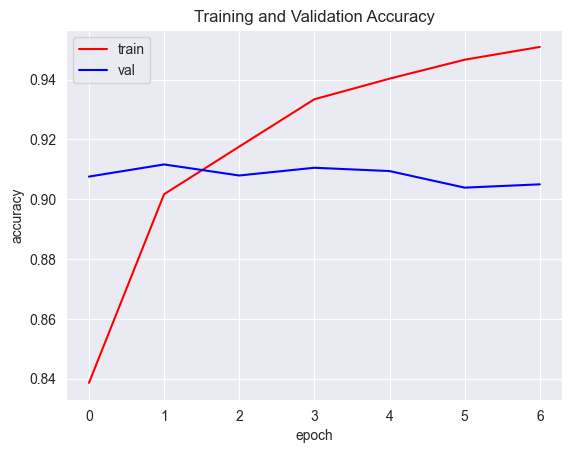

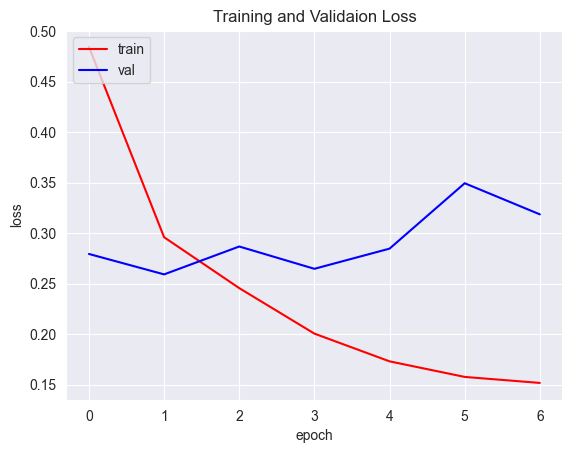

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [ ]:
# Save model
model.save("model.keras")
model.save("best_model.h5")

## Konversi Model

In [ ]:
# Format Saved Model
model.export("saved_model")

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32, name='keras_tensor_1935')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2451409603664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151089552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151089360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451409603472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151079376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151083600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151077840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151080528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151092816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151081680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2451151081104: TensorSpec(shape=()

In [ ]:
# Format TF-Lite
os.makedirs("tflite", exist_ok=True)

# Simpan model TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()
with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

# Simpan label.txt ke TFLite
class_names = list(train_gen.class_indices.keys())
with open("tflite/labels.txt", "w") as f:
    f.write("\n".join(class_names))

In [3]:
INPUT_MODEL_PATH = "best_model.keras"

# Muat model
model = tf.keras.models.load_model(INPUT_MODEL_PATH)

# Convert model
tfjs.converters.save_keras_model(model, 'tfjs')

failed to lookup keras version from the file,
    this is likely a weight only file


## Inference (Optional)

Unggah gambar untuk diprediksi:


Saving 30.jpg to 30.jpg


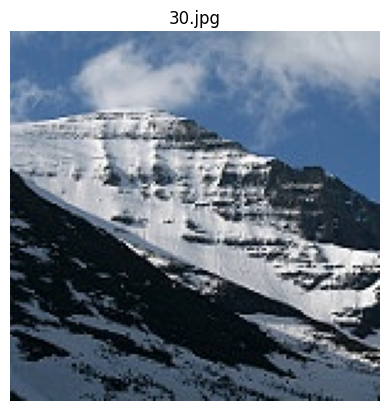

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

--- Hasil Prediksi ---
Kelas: glacier
Keyakinan: 86.97%


In [5]:
from google.colab import files

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
TARGET_SIZE = (244, 244)

def predict_uploaded_image(model, class_names, target_size):

    # 1. Input Gambar
    print("Unggah gambar untuk diprediksi:")
    uploaded = files.upload()
    if not uploaded: return

    file_name = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[file_name]))

    # 2. Pra-pemrosesan
    plt.imshow(img); plt.title(file_name); plt.axis('off'); plt.show()

    img = img.resize(target_size)
    img_array = np.asarray(img, dtype=np.float32) / 255.0
    input_tensor = np.expand_dims(img_array, axis=0)

    # 3. Inferensi
    predictions = model.predict(input_tensor)
    probabilities = predictions[0]

    # 4. Interpretasi Multiclass
    predicted_index = np.argmax(probabilities)
    predicted_class_name = class_names[predicted_index]
    confidence = probabilities[predicted_index]

    # 5. Output
    print("\n--- Hasil Prediksi ---")
    print(f"Kelas: {predicted_class_name}")
    print(f"Keyakinan: {confidence * 100:.2f}%")

# --- JALANKAN ---
predict_uploaded_image(model, CLASS_NAMES, TARGET_SIZE)

Unggah gambar untuk diprediksi:


Saving 233.jpg to 233.jpg


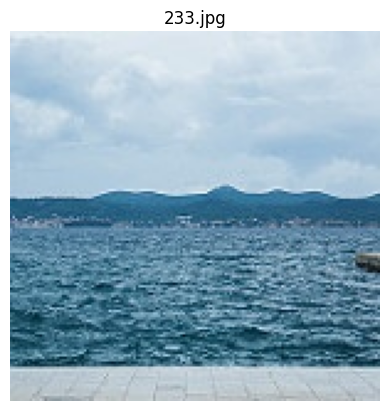

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

--- Hasil Prediksi ---
Kelas: sea
Keyakinan: 99.97%


In [7]:
predict_uploaded_image(model, CLASS_NAMES, TARGET_SIZE)

Unggah gambar untuk diprediksi:


Saving 88.jpg to 88.jpg


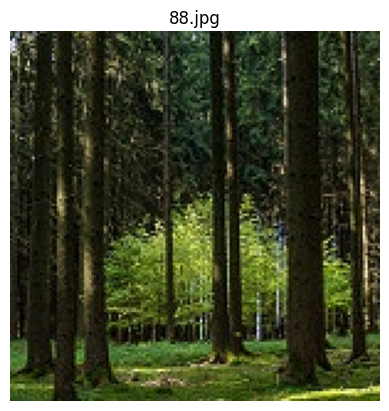

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

--- Hasil Prediksi ---
Kelas: forest
Keyakinan: 100.00%


In [8]:
predict_uploaded_image(model, CLASS_NAMES, TARGET_SIZE)